# Forced Torsional Response HelloWorld

This notebook is a minimal, test-backed example for `calc_forced_tors_resp`, using inputs mirrored from `python/tests/test_calc_forced_tors_resp.py`.

In [15]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from matplotlib.figure import Figure
from IPython.display import Image, display


# Make package imports work when running from workspace root or notebooks/.
cwd = Path.cwd()
candidate_roots = [cwd, cwd.parent]
python_src = None
for root in candidate_roots:
    maybe = root / "python"
    if maybe.exists():
        python_src = maybe
        break

if python_src is None:
    raise RuntimeError("Could not locate project python/ directory from current working directory")

if str(python_src) not in sys.path:
    sys.path.insert(0, str(python_src))

from vibration_analysis.torsional.calc_forced_tors_resp import calc_forced_tors_resp

## Example 1: Three-Mass System

This matches the first unit test and should return two non-zero natural frequencies.

In [16]:
d_moip = [1.0, 2.0, 3.0]
d_kt = [1.0, 2.0, 0.0]
d_len = [1.0, 1.0, 1.0]
d_damp_int = [1e-2, 2e-2, 0.0]
d_damp_ext = [1e-10, 2e-10, 3e-10]
d_obs = [1, 1, 1, 0, 0, 0]

h3, d_eigvec, omega_cpm, h_mass_elastic, ss_rotor, *_ = calc_forced_tors_resp(
    d_moip,
    d_kt,
    d_len,
    d_damp_int,
    d_damp_ext,
    d_obs,
)

print("Eigenvector matrix shape:", d_eigvec.shape)
print("Natural frequencies (CPM):", omega_cpm)
print("State-space A shape:", ss_rotor['A'].shape)
print("State-space C shape:", ss_rotor['C'].shape)

Eigenvector matrix shape: (3, 2)
Natural frequencies (CPM): [ 8.91381197 14.46752673]
State-space A shape: (6, 6)
State-space C shape: (3, 6)


In [17]:
omega_expected = np.array([8.9138119652212137794, 14.467526728136422258])
print("Expected (test) frequencies:", omega_expected)
print("Absolute error:", np.abs(omega_cpm[:2] - omega_expected))

Expected (test) frequencies: [ 8.91381197 14.46752673]
Absolute error: [1.77635684e-15 1.77635684e-15]


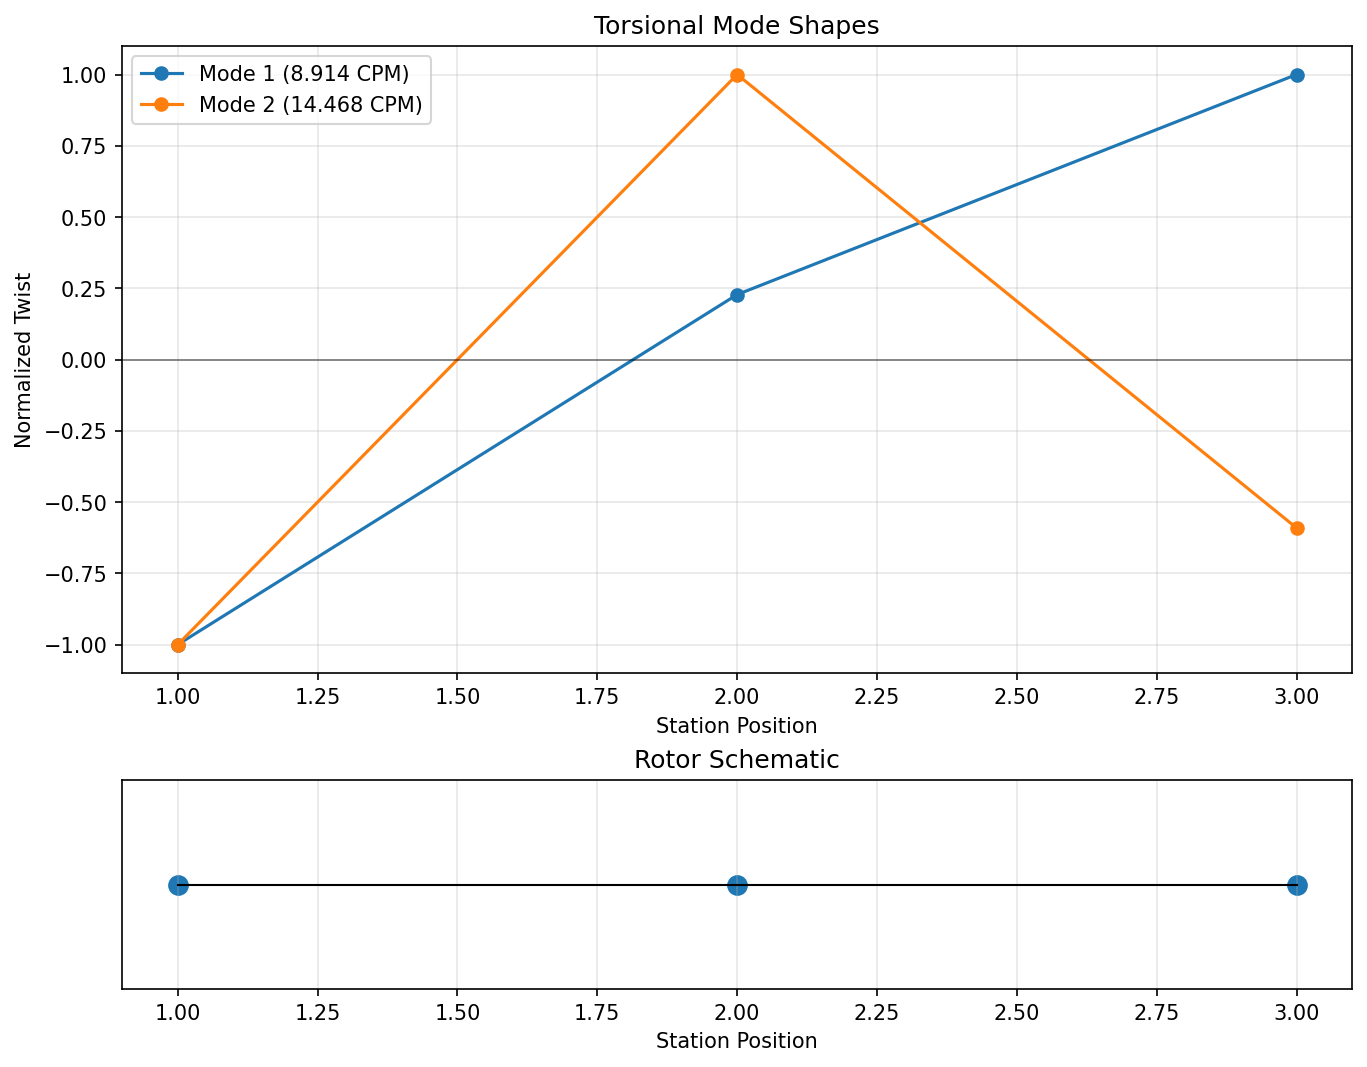

In [18]:
if isinstance(h3, Figure):
    buffer = BytesIO()
    h3.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
else:
    print("No Matplotlib figure handle returned in this configuration.")

## Example 2: Two-Mass System with External Stiffness

This mirrors the uncertainty + external stiffness test case.

In [19]:
d_moip = [1.0, 2.0]
d_u_moip = [0.01, 0.02]
d_kt = [3.0, 0.0]
d_u_kt = [0.04, 0.0]
d_kt_ext = [0.5, 0.25]
d_u_kt_ext = [0.04, 0.02]
d_len = [1.0, 1.0]
d_damp_int = [3e-2, 0.0]
d_damp_ext = [1e-4, 2e-4]
d_obs = [1, 1, 0, 0]

h2, d_eigvec2, omega_cpm2, h_mass_elastic2, ss_rotor2, *_ = calc_forced_tors_resp(
    d_moip,
    d_kt,
    d_len,
    d_damp_int,
    d_damp_ext,
    d_obs,
    1,
    -1,
    b_no_plots=False,
    b_supr_degen=False,
    d_kt_ext=d_kt_ext,
    d_u_MoIp=d_u_moip,
    d_u_kt=d_u_kt,
    d_u_kt_ext=d_u_kt_ext,
)

print("Natural frequencies (CPM):", omega_cpm2)
print("First mode shape first value:", d_eigvec2[0, 0])
print("A matrix:\n", ss_rotor2["A"])

Natural frequencies (CPM): [ 4.70977935 21.09886106]
First mode shape first value: 1.0
A matrix:
 [[ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]
 [-3.5     3.     -0.0301  0.03  ]
 [ 1.5    -1.625   0.015  -0.0151]]


## Optional: Display Generated Plot Handle

If plotting is enabled and a Matplotlib figure handle is returned, this will render it inline.

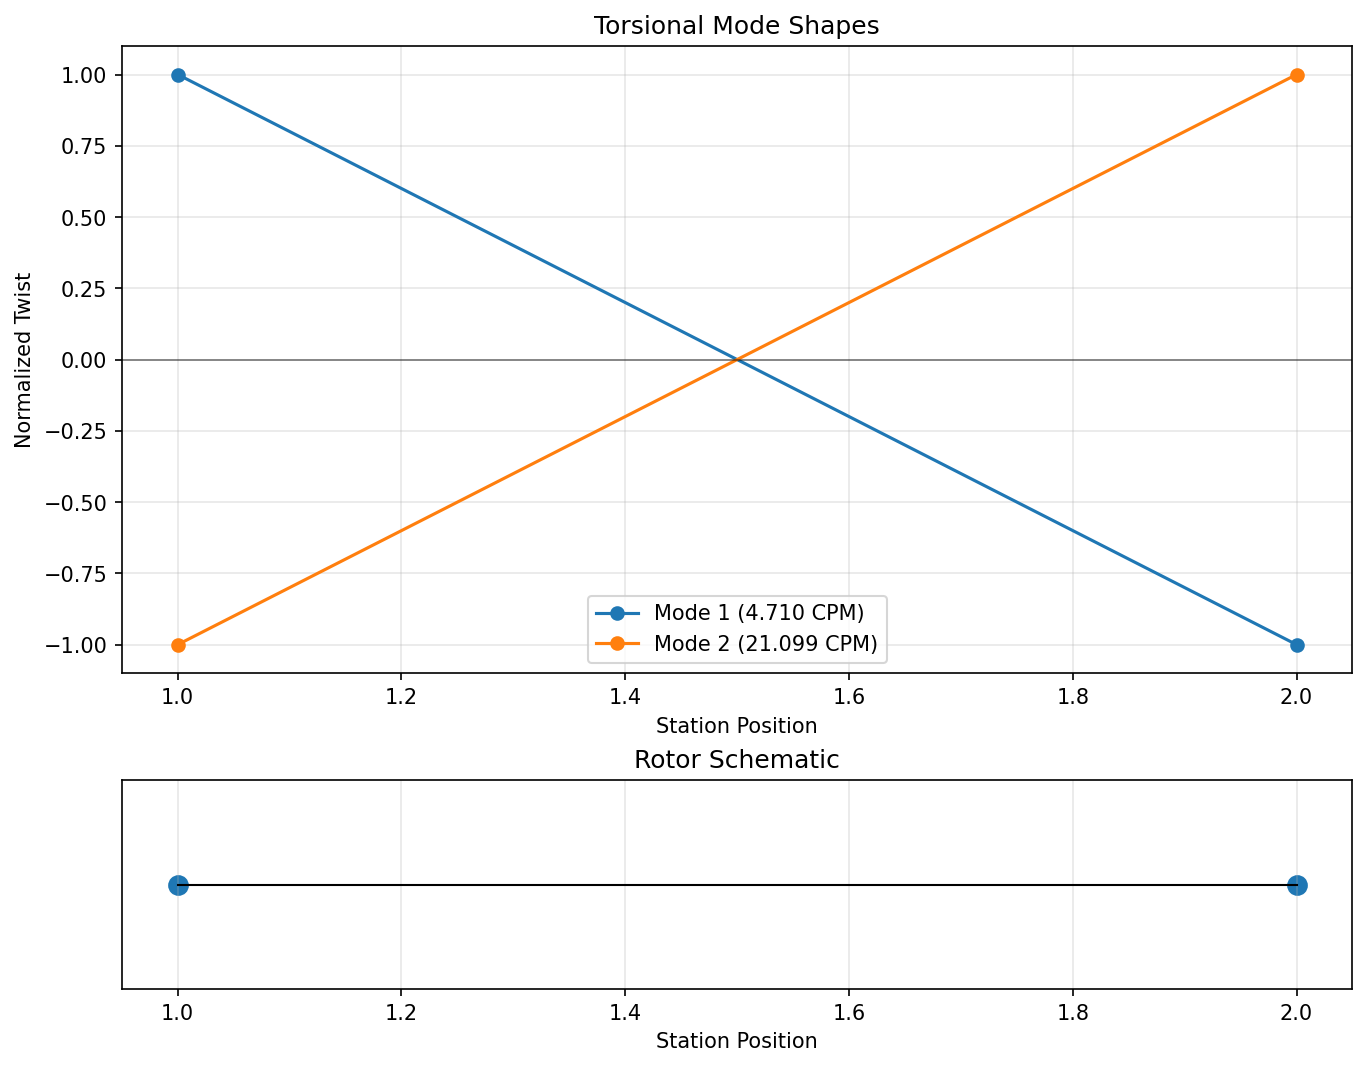

In [20]:
if isinstance(h2, Figure):
    buffer = BytesIO()
    h2.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
else:
    print("No Matplotlib figure handle returned in this configuration.")